# Training code for 3D seismic reconstruction using UFNO 
<div style="text-align: right;">
<b>Authors:
    Yang Cui & Alessandro</b>
</div>

In [1]:
'''
The official training code for ML competition
"Leaning a Robust 3D Seismic Reconstruction Operator Using UFNO"
Authors: Yang Cui & Alessandro Traversa
Email: yang.cui512@gmail.com
'''
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../')

import torch.nn.functional as F
import torch.nn as nn
from timeit import default_timer
import matplotlib.pyplot as plt
import torch
import numpy as np
from utils import *
from U_net import *
import cigsegy
from cigsegy import SegyNP
import time
from torch.utils.data import DataLoader, TensorDataset, random_split
from pylops.basicoperators import *
from torchmetrics.image import PeakSignalNoiseRatio
from torch.cuda.amp import GradScaler, autocast
# Check for CUDA availability and set the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 2025
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


import os 
loss_path = "../figs/loss/"
model_path = "../model/"

os.makedirs(loss_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

In [2]:
# ------------------------------
# 4) Missing Data Generators
# ------------------------------
def random_missing(cube, ratio, seed=None):
    """
    Random missing using utils.genmask if available; else Bernoulli with (1-ratio) keep prob.
    ratio = fraction removed in [0,1]
    """
    in1, in2, in3 = cube.shape
    if genmask is not None:
        mask = genmask((cube.T).reshape(in2, in1*in3, order='F'), ratio, 'r', 201415)
        mask = mask.reshape(in1, in2, in3, order='F').astype(np.float32)
    else:
        rng = np.random.default_rng(seed)
        mask = (rng.random((in1, in2, in3)) > ratio).astype(np.float32)
    return cube * mask

def fully_random_missing(cube, ratio, seed=10):
    """
    Fully random irregular missing using pylops + utils.irregular2 if available.
    Fallback to random_missing otherwise.
    """
    in1, in2, in3 = (cube.T).shape
    if _HAS_PYLOPS and irregular2 is not None:
        iava, _ = irregular2(in1, in2, in3, perc_sub=ratio, seed=seed)
        Rop = Restriction(dims=in1*in2*in3, iava=iava, dtype='float64')
        mask = (Rop.H * Rop * np.ones_like(cube).ravel()).reshape(in1, in2, in3).astype(np.float32)
        return cube * mask
    return random_missing(cube.T, ratio, seed=seed)

def regular_missing(cube, n, mode="inline"):
    """
    Regular missing along axis directions.
      mode: "inline" | "crossline" | "both" (intersection) | "all" (intersection of all 3)
    Keep every n-th trace (1/n kept) with a random offset per axis.
    """
    in1, in2, in3 = (cube.T).shape
    mask = np.ones((in1, in2, in3), dtype=np.float32)

    if mode in ["inline", "both", "all"]:
        o1 = np.random.randint(0, n)
        kept1 = list(range(o1, in1, n))
        m1 = np.zeros_like(mask); m1[kept1, :, :] = 1.0
        mask = m1 if mode == "inline" else mask * m1

    if mode in ["crossline", "both", "all"]:
        o2 = np.random.randint(0, n)
        kept2 = list(range(o2, in2, n))
        m2 = np.zeros_like(mask); m2[:, kept2, :] = 1.0
        mask = m2 if mode == "crossline" else mask * m2

    if mode == "all":
        o3 = np.random.randint(0, n)
        kept3 = list(range(o3, in3, n))
        m3 = np.zeros_like(mask); m3[:, :, kept3] = 1.0
        mask = mask * m3

    return cube * mask

def regular_line_grid_mask_xy(shape, strides=(4,4), offsets=(0,0), dtype=np.float32):
    """
    Generate a mask with regular missing along both inline (X) and crossline (Y).
    - strides = (sx, sy): keep every sx-th inline and every sy-th crossline
    - offsets = (ox, oy): starting offsets to avoid always beginning at 0
    - The Z dimension is fully preserved (no subsampling along time/depth).
    """
    nx, ny, nz = shape
    sx, sy = strides
    ox, oy = offsets
    if sx < 1 or sy < 1:
        raise ValueError("sx, sy must be >= 1")

    ox %= sx
    oy %= sy

    # Create a 2D mask in XY plane
    mask2d = np.zeros((ny, nz), dtype=dtype)
    # Keep full inline lines (x ≡ ox mod sx)
    mask2d[ox::sx, :] = 1.0
    # Keep full crossline lines (y ≡ oy mod sy)
    mask2d[:, oy::sy] = 1.0

    # Expand to 3D by repeating along Z
    mask3d = np.repeat(mask2d[None, :, :], nx, axis=0).astype(dtype)
    return mask3d


# ------------------------------
# 5) Visualization Helper
# ------------------------------
def visualize_cube(cube, inline=None, crossline=None, depth=None, cmap="seismic"):
    """Show three orthogonal slices of a 3D cube."""
    nx, ny, nz = cube.shape
    if inline is None: inline = nx // 2
    if crossline is None: crossline = ny // 2
    if depth is None: depth = nz // 2

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(cube[inline, :, :].T, cmap=cmap, aspect="auto", origin="lower")
    axs[0].set_title(f"Inline {inline}")

    axs[1].imshow(cube[:, crossline, :].T, cmap=cmap, aspect="auto", origin="lower")
    axs[1].set_title(f"Crossline {crossline}")

    axs[2].imshow(cube[:, :, depth], cmap=cmap, aspect="auto", origin="lower")
    axs[2].set_title(f"Depth {depth}")

    plt.tight_layout(); plt.show()


## load training patches

In [3]:
# Paths to data
F3_path = os.getenv('HOME') + '/Yang/Data/ML_competition/F3/'
Moomba_path = os.getenv('HOME') + '/Yang/Data/ML_competition/Manba/'
Filt_mig_path = os.getenv('HOME') + '/Yang/Data/ML_competition/Filt_mig/'

# Patch size
l1, l2, l3 = 128, 128, 128

# Load datasets
f3_patches_3d = np.load(f'{F3_path}F3_filtered_patch_data_{l1}_{l2}_{l3}.npy')
moomba_patches_3d = np.load(f'{Moomba_path}Moomba_filtered_patch_data_{l1}_{l2}_{l3}.npy')
filt_mig_patches_3d = np.load(f'{Filt_mig_path}Filt_filtered_patch_data_{l1}_{l2}_{l3}.npy')
print(f'F3: {f3_patches_3d.shape}\nMoomba: {moomba_patches_3d.shape}\nFilt_mig: {filt_mig_patches_3d.shape}')


# Combine datasets
combine_data = np.concatenate([f3_patches_3d, moomba_patches_3d, filt_mig_patches_3d], axis=0)
print(f'Combined data shape: {combine_data.shape}')

F3: (330, 128, 128, 128)
Moomba: (490, 128, 128, 128)
Filt_mig: (162, 128, 128, 128)
Combined data shape: (982, 128, 128, 128)


## generate training data 

(128, 128, 128)


<Figure size 1000x1000 with 0 Axes>

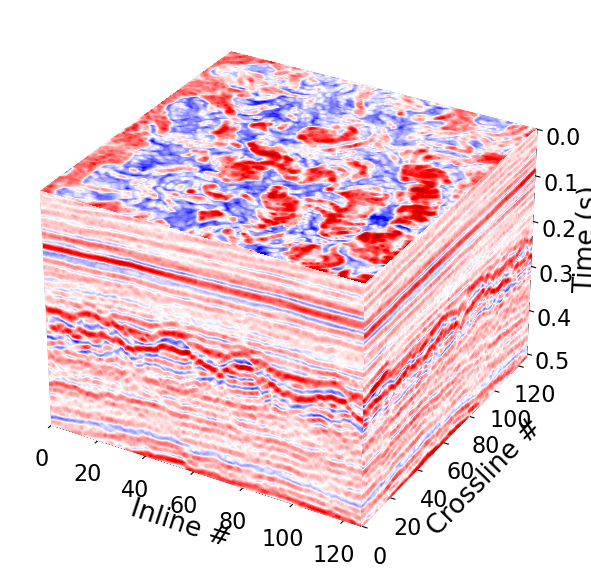

In [4]:
dataxx = combine_data[8, :, :, :]
#dataxx = rand_cube[0, :, :, :]
print(dataxx.shape)
nz = dataxx.shape[0]
nx = dataxx.shape[1]
ny = dataxx.shape[2]
dt = 0.004
nt = dataxx.shape[0]
dz=1


plt.figure(figsize=(10, 10))
plot3d(dataxx,z=np.arange(nz)*dt,x=np.arange(nx)*dz,y=np.arange(ny)*dz,showf=False,close=False)
plt.gca().set_xlabel("Inline #",fontsize='large', fontweight='normal')
plt.gca().set_ylabel("Crossline #",fontsize='large', fontweight='normal')
plt.gca().set_zlabel("Time (s)",fontsize='large', fontweight='normal')
# plt.title('F3 Data', fontweight='bold')
plt.tight_layout()
#plt.savefig(fname='./Figs/Filt_mig_data_stacked.png',format='png',dpi=300)
plt.show()

In [5]:
################################################################
# Generate training data
################################################################
# Initialize lists
rand_cube, frand_cube, reg_grid_cube, gap_cube = [], [], [], []


# 1. Random Missing (100 cubes)
for ii in range(0, 250):
    randn_data = combine_data[ii, :, :, :].T  # Shape: (128, 128, 128)
    in1, in2, in3 = randn_data.shape
    ratio = round(random.uniform(0.10, 0.95), 2)
    
    # Generate random mask
    mask = genmask(randn_data.reshape(in2, in1*in3, order='F'), ratio, 'r', 201415)
    mask = mask.reshape(in1, in2, in3, order='F')
    rand_mask_cube = randn_data * mask
    rand_mask_cube = rand_mask_cube.T
    rand_cube.append(rand_mask_cube)
rand_cube = np.array(rand_cube)  # Shape: (100, 128, 128, 128)
print('*************random missing finish****************')


# 2. Fully Random Missing (200 cubes)
for ii in range(250, 500):
    frandn_data = combine_data[ii, :, :, :].T
    in1, in2, in3 = frandn_data.shape
    ratio = round(random.uniform(0.1, 0.95), 2)
    
    # Generate irregular mask
    iava, iavarec = irregular2(in1, in2, in3, perc_sub=ratio, seed=10)
    Rop = Restriction(dims=in1*in2*in3, iava=iava, dtype='float64')
    mask = (Rop.H * Rop * np.ones_like(frandn_data).ravel()).reshape(in1, in2, in3)
    frand_mask_cube = frandn_data * mask
    frand_mask_cube = frand_mask_cube.T
    frand_cube.append(frand_mask_cube)
frand_cube = np.array(frand_cube)  # Shape: (200, 128, 128, 128)
print('*************fully random missing finish****************')


# Typical stride choices (you can adjust them to control density)
stride_choices = [(2,4), (3,3), (4,4), (4,6), (6,6), (8,8)]

for ii in range(500, 750):
    data = combine_data[ii, :, :, :]  # (128, 128, 128)

    sx, sy = random.choice(stride_choices)
    ox = random.randrange(sx)  # inline offset
    oy = random.randrange(sy)  # crossline offset

    mask = regular_line_grid_mask_xy(
        data.shape,
        strides=(sx, sy),
        offsets=(ox, oy),
        dtype=np.float32
    )
    masked_cube = (data * mask).astype(data.dtype)

    reg_grid_cube.append(masked_cube)

reg_grid_cube = np.array(reg_grid_cube)  # (100, 128, 128, 128)
# reg_xyline_masks = np.array(reg_xyline_masks)  # uncomment if you also want to save masks
print('*************regular missing (inline & crossline lines) finished****************')


# Combine training data and masks
Train_data = np.concatenate([rand_cube, frand_cube, reg_grid_cube], axis=0)

print(f'Training data shape: {Train_data.shape}')

label_data= combine_data[:Train_data.shape[0]]

*************random missing finish****************
*************fully random missing finish****************
*************regular missing (inline & crossline lines) finished****************
Training data shape: (750, 128, 128, 128)


## Training and validation data splitting 

In [6]:
batch_size = 2
label_data = combine_data
X = torch.Tensor(Train_data).unsqueeze(1)
Y = torch.Tensor(label_data[:Train_data.shape[0], :, :, :]).to(device)
print(X.shape, Y.shape)
train_a = X
train_u = Y 

dataset = TensorDataset(train_a, train_u)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# Print sizes of the datasets
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

torch.Size([750, 1, 128, 128, 128]) torch.Size([750, 128, 128, 128])
Training dataset size: 675
Validation dataset size: 75


## Hyperparameter setup

In [7]:
in_channels=1
out_channels=1
epochs = 200
e_start = 0
learning_rate = 0.0005
scheduler_step = 2
scheduler_gamma = 0.9

model = UNet3(n_channels=in_channels,n_classes=out_channels )
model.to(device)

UNet3(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (4): BatchNorm3d(32, eps=1e-05, momentum=0

## Model training

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.MSELoss().to(device)
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
scaler = GradScaler()

################################################################ 
# Model training
################################################################
train_losses, val_losses, val_ssims, val_psnrs = [], [], [], []
best_val_loss = float('inf')
patience = 20
counter = 0

# Initialize metrics logging
metrics_file = f'{loss_path}Metrics_UNET_3D_recon_all_width_ep{epochs}_num{Train_data.shape[0]}.txt'
with open(metrics_file, 'w') as f:
    f.write('Epoch,Train_Loss,Val_Loss,Val_SSIM,Val_PSNR\n')

for ep in range(1, epochs + 1):
    model.train()
    t1 = default_timer()
    train_l2 = 0
    counter = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        # print(x.shape, y.shape)
        # x = augment(x)
        
        optimizer.zero_grad()
        # with autocast():
        pred = model(x)
        # print(pred.shape)
        loss = criterion(pred.unsqueeze(0), y)
        loss.backward()
        optimizer.step()
        
        train_l2 += loss.item()
        counter += 1
        if counter % 100 == 0:
            print(f'epoch: {ep}/{epochs}, batch: {counter}/{len(train_loader)}, train loss: {loss.item()/batch_size:.4f}')   
    
    scheduler.step()
    avg_train_loss = train_l2 / len(train_loader)
    train_losses.append(avg_train_loss)
    
    print(f'epoch: {ep}/{epochs}, batch: {counter}/{len(train_loader)}, train loss: {avg_train_loss:.4f}')

    # Validation phase
    model.eval()
    val_l2, val_psnr = 0, 0
    cube_visualized = True 
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            # with autocast():
            pred_val = model(x_val)
            pred_samples = pred_val.cpu().detach().numpy()
            # print('val shape:', pred_samples.shape)
            if not cube_visualized:
                dataxx = pred_samples  # First cube in batch
                nz, nx, ny = dataxx.shape
                dz, dt = 1, 0.004
                
                plt.figure(figsize=(10, 10))
                plot3d(
                    dataxx,
                    z=np.arange(nz) * dt,
                    x=np.arange(nx) * dz,
                    y=np.arange(ny) * dz,
                    showf=False,
                    close=False
                )
                plt.gca().set_xlabel("Inline #", fontsize='large', fontweight='normal')
                plt.gca().set_ylabel("Crossline #", fontsize='large', fontweight='normal')
                plt.gca().set_zlabel("Time (s)", fontsize='large', fontweight='normal')
                plt.title(f'Epoch {ep}: Pred. cube', fontweight='bold')
                plt.tight_layout()
                # plt.close()
                # cube_visualized = True

            val_l2 += criterion(pred_val.unsqueeze(0), y_val).item()
            # val_ssim += criterion.ssim(pred_val.unsqueeze(0), y_val).item()
            val_psnr += psnr(pred_val.unsqueeze(0), y_val).item()
    
    avg_val_loss = val_l2 / len(val_loader)
    # avg_val_ssim = val_ssim / len(val_loader)
    avg_val_psnr = val_psnr / len(val_loader)
    val_losses.append(avg_val_loss)
    # val_ssims.append(avg_val_ssim)
    val_psnrs.append(avg_val_psnr)
    
    # Log metrics to file
    with open(metrics_file, 'a') as f:
        f.write(f'{ep},{avg_train_loss:.6f},{avg_val_loss:.6f},{avg_val_psnr:.6f}\n')
    
    t2 = default_timer()
    print(f'epoch: {ep}/{epochs}, val loss: {avg_val_loss:.4f}, PSNR: {avg_val_psnr:.4f}, Time: {t2 - t1:.4f}s')

epoch: 1/200, batch: 100/675, train loss: 0.1134
epoch: 1/200, batch: 200/675, train loss: 1.0491
epoch: 1/200, batch: 300/675, train loss: 0.0964
epoch: 1/200, batch: 400/675, train loss: 0.3155
epoch: 1/200, batch: 500/675, train loss: 0.0945
epoch: 1/200, batch: 600/675, train loss: 0.6791
epoch: 1/200, batch: 675/675, train loss: 0.3104
epoch: 1/200, val loss: 0.2183, PSNR: 8.3538, Time: 86.2333s
epoch: 2/200, batch: 100/675, train loss: 0.5567
epoch: 2/200, batch: 200/675, train loss: 0.1112
epoch: 2/200, batch: 300/675, train loss: 0.1551
epoch: 2/200, batch: 400/675, train loss: 0.1860
epoch: 2/200, batch: 500/675, train loss: 0.1055
epoch: 2/200, batch: 600/675, train loss: 0.1723
epoch: 2/200, batch: 675/675, train loss: 0.2141
epoch: 2/200, val loss: 0.2851, PSNR: 6.9871, Time: 87.7290s
epoch: 3/200, batch: 100/675, train loss: 0.2013
epoch: 3/200, batch: 200/675, train loss: 0.0875
epoch: 3/200, batch: 300/675, train loss: 0.2334
epoch: 3/200, batch: 400/675, train loss: 0.1

In [9]:
torch.save(model.state_dict(), f"{model_path}UNET_3D_recon_all_modes_ep{ep}_num{Train_data.shape[0]}_all_types_Yang.pth")

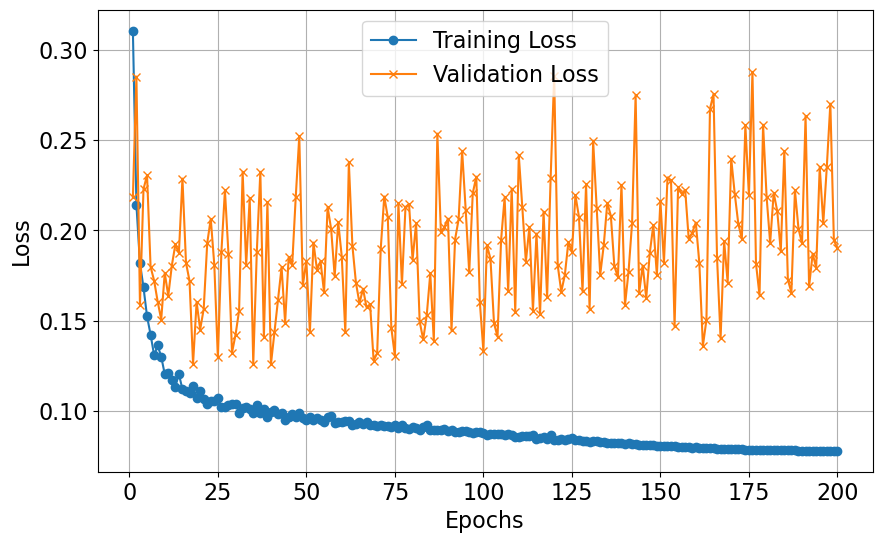

In [10]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.savefig(f'{loss_path}Loss_unet_3D_recon_all_ep{epochs}_num{Train_data.shape[0]}.png', dpi=300)
plt.show()